# 11_数据预处理方法-数据转换

## Notebook 使用说明

建议先阅读理论，再从上到下运行全部单元；使用 Python 3.11–3.13 内核。数据与辅助模块均来自本文件夹，安装依赖后无需联网获取案例数据。

本篇数据：`dataset/house-prices-advanced-regression-techniques/train.csv`。

转写调整：

- 修复或适配代码；原讲解性输出保留为 Markdown，Python 单元按顺序执行。

原文参考图及静态数值仅用于对照；重跑后的代码输出为本次实验结果。依赖版本与验证记录见根目录 `README.md` 和 `reports/`。

In [1]:
# 从当前目录向上寻找本套 Notebook 的根目录，移动整个文件夹后仍可运行。
from pathlib import Path
import os, sys, tempfile, random
ROOT = next((p for p in [Path.cwd(), *Path.cwd().parents]
             if (p / "notebook_support.py").is_file()), None)
if ROOT is None:
    raise FileNotFoundError("请从这套 Notebook 文件夹内启动 Jupyter，并保留 notebook_support.py。")
sys.path.insert(0, str(ROOT))
os.environ.setdefault("MPLCONFIGDIR", str(Path(tempfile.gettempdir()) / "ml_notebooks_matplotlib"))
from notebook_support import DATA_DIR, load_local_housing, load_local_boston, load_local_mnist, load_creditcard
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib import font_manager
random.seed(42)
np.random.seed(42)
# 按实际安装的字体选择，兼容 macOS / Windows / Linux。
_available_fonts = {f.name for f in font_manager.fontManager.ttflist}
CJK_FONTS = [f for f in ["Arial Unicode MS", "PingFang SC", "Heiti TC", "Microsoft YaHei", "SimHei", "Noto Sans CJK SC"]
             if f in _available_fonts] + ["DejaVu Sans"]
plt.rcParams.update({"font.sans-serif": CJK_FONTS, "axes.unicode_minus": False,
                     "figure.dpi": 90, "figure.max_open_warning": 30})
%matplotlib inline


今儿和大家分享一下数据预处理方法方面的数据转换\~

#### 首先，什么是「数据转换」？

数据转换是指把原始数据按照一定的方式“变一变”，变成更适合分析或建模使用的格式，把原始数据整理成模型能理解、能用的样子。

#### 常见的数据转换方法

**1. 标准化 / 归一化（把数据缩放到同一个范围）**

比如有些人的工资是几千，有些人的消费记录是几块钱，这样的数据差别太大了，模型不好学习。我们可以把它们按比例压缩到0到1之间，或让它们的平均值变成0，这样更容易进行比较和分析。

举例：

原始数据：身高 [160, 170, 180]

归一化后：[0, 0.5, 1]

**2. 类型转换（比如把文字变成数字）**

有时候数据中会有文字信息，比如“男”“女”或“高”“中”“低”等，但模型只能处理数字，所以我们需要把这些文字转换成数字。

举例：

性别列：["男", "女", "男"]

转换后：[1, 0, 1]（男 = 1，女 = 0）

**3. 分箱（把连续的数据变成分组或等级）**

当我们不关心具体的数值，而是关心数据属于哪个范围时，可以进行分箱处理。

举例：

年龄：[22, 35, 58]

分箱后：["青年", "中年", "老年"]

**4. 对数转换（缩小数值差距）**

当数据跨度太大，比如收入从几百到几百万，可以取对数，让数据更平稳，更容易处理。

举例：

收入：[1000, 10000, 1000000]

转换后：[3, 4, 6]（以10为底的对数）

总之，数据转换的目的是让数据变得更“规整”、更适合模型学习。它是数据预处理中的重要一步，几乎所有数据分析和机器学习项目都会用到。

## 原理部分

这里，咱们介绍数学方面的表示以及多个常用的转换技术\~

### 一、数据转换（数学层面）

将原始数据 $X = \{x_1, x_2, ..., x_n\}$ 通过某个变换函数 $f$，映射到新的空间或分布中，得到新数据 $X' = \{x_1', x_2', ..., x_n'\}$，其中：


$$
x_i' = f(x_i)
$$


这个变换可以是线性变换、非线性变换、分段函数、分类编码等形式。

### 二、常见数据转换方法

#### 1. 标准化（Z-score 标准化）

将数据转换为**均值为 0，标准差为 1**的正态分布。适用于假设数据是高斯分布的模型，如线性回归、逻辑回归等。

给定一组数据 $X = \{x_1, x_2, ..., x_n\}$，其均值为：


$$
\mu = \frac{1}{n} \sum_{i=1}^n x_i
$$


标准差为：


$$
\sigma = \sqrt{ \frac{1}{n} \sum_{i=1}^n (x_i - \mu)^2 }
$$


标准化后的数据为：


$$
z_i = \frac{x_i - \mu}{\sigma}
$$


该转换使数据均值为0，标准差为1，有助于提高梯度下降的收敛速度，并消除不同特征量纲差异对模型的影响。

#### 2. 归一化（Min-Max 归一化）

将数据线性地压缩到特定的区间，如 [0, 1] 或 [-1, 1]。

设最大值为 $x_{\max}$，最小值为 $x_{\min}$，则归一化为 [0, 1] 的公式为：


$$
x_i' = \frac{x_i - x_{\min}}{x_{\max} - x_{\min}}
$$


或者归一化为 [-1, 1]：


$$
x_i' = 2 \cdot \frac{x_i - x_{\min}}{x_{\max} - x_{\min}} - 1
$$


通过缩放操作将不同范围的数据拉到统一尺度，使得模型的数值计算更稳定。特别适用于神经网络和距离相关的算法（如KNN、SVM）。

#### 3. 对数转换（Log Transform）

用于处理右偏（正偏）分布的数据。

通过对数函数将大数压缩，小数拉伸，减少数据的偏态和异常值影响。


$$
x_i' = \log_b(x_i + c)
$$


其中：

- $b$ 为对数的底数（常用 $e$ 或 10）
- $c \geq 0$ 用于防止 $x_i = 0$ 时无法取对数

**推理过程：**

对数函数 $f(x) = \log_b(x)$ 的一阶导数是：


$$
f'(x) = \frac{1}{x \ln b}
$$


说明对数变化在 $x$ 增大时变化减缓，从而压缩了极大值，提高模型的稳定性和抗噪能力。

#### 4. Box-Cox 变换（广义幂变换）

用于将非正态分布的数据变成近似正态分布。

对于 $x_i > 0$，Box-Cox变换定义为：


$$
x_i' =\begin{cases}\frac{x_i^{\lambda} - 1}{\lambda}, & \lambda \neq 0 \\\log(x_i), & \lambda = 0\end{cases}
$$


通过调节参数 $\lambda$，可以控制数据的偏度和峰度。利用最大似然估计法（MLE）寻找最优 $\lambda$ 使变换后数据最接近正态分布。

#### 5. 分箱（Binning）

将连续数值变量划分为离散类别，便于模型学习非线性关系或提升鲁棒性。

等宽分箱（Equal-width）：

若将区间划为 $k$ 个等宽区间，则每个区间宽度为：


$$
w = \frac{x_{\max} - x_{\min}}{k}
$$


则第 $j$ 个区间为：


$$
[x_{\min} + (j-1)w, x_{\min} + jw)
$$


等频分箱（Equal-frequency）：

将样本按大小排序后，按样本数量均分成 $k$ 个区间。

简化模型输入，提高解释性，减少噪声影响。尤其适用于决策树等模型。

#### 6. One-Hot 编码（独热编码）

将分类变量转换为向量形式，使其可以用于只能处理数值数据的模型。

假设有分类变量取值集合 $C = \{c_1, c_2, ..., c_k\}$，对于每个分类 $c_j$，我们定义一个 k 维向量：


$$
v_j = (0, ..., 0, 1, 0, ..., 0)
$$


其中第 $j$ 位为1，其余为0。

保持类别间等距关系，避免模型误解类别间有大小顺序（例如"小" < "中" < "大"）。但维度会随类别数变高，增加计算资源。

#### 7. **主成分分析（PCA）作为一种转换方法**

线性变换，将原始特征映射到一个新的坐标轴上，新坐标轴为数据协方差矩阵的特征向量方向，按信息保留度降维。

1. 计算数据的协方差矩阵 $\Sigma = \frac{1}{n} X^T X$
2. 计算协方差矩阵的特征值 $\lambda_i$ 和对应特征向量 $v_i$
3. 选取前 $k$ 个最大的特征值，对应的特征向量 $V_k$
4. 变换结果：


$$
X' = X V_k
$$


通过保留最大方差信息的方向，达到降维和去相关的目的，提高建模效率。

## 数据转换整体流程

这里是一个常见的数据转换操作流程（算法框架）：

1. **收集数据** $X$
2. **选择转换方法**：根据数据类型和分布选择适合的变换函数 $f$
3. **估算必要参数**（如均值、方差、最大值、最小值、最优 $\lambda$）
4. **应用变换函数**：


$$
x_i' = f(x_i)
$$


1. **验证转换效果**：

   - 可视化（例如画分布图）
   - 检查是否满足模型输入要求（如是否服从正态分布、是否为数值等）

## 汇总数据转换核心点

| 方法 | 数学核心 | 应用场景 |
|-|-|-|
| 标准化 | 减均值除以标准差 | 高斯分布假设的模型 |
| 归一化 | 线性缩放到特定区间 | 深度学习、KNN等距离敏感模型 |
| 对数变换 | 应对数据偏态，压缩大数 | 收入、价格等大尺度变量 |
| Box-Cox变换 | 参数化幂函数拟合近似正态分布 | 统计建模，预测模型 |
| 分箱 | 将连续变量离散化 | 决策树模型、业务规则建模 |
| One-Hot编码 | 分类变量转为数值向量 | 所有不支持分类变量的算法 |
| PCA | 基于特征值分解进行线性降维 | 降维、特征冗余消除 |

## 完整案例

**项目名称：房价预测数据中的特征转换分析与可视化**

咱们数据集使用**Kaggle House Prices** 数据集（大家可从 https://www.kaggle.com/c/house-prices-advanced-regression-techniques/data 下载）。

或者在公众号后台回复「数据集」，找到house-prices-advanced-regression-techniques.zip 文件。

这里的案例，应用多个**数据转换算法（归一化、对数变换、分箱、独热编码、PCA）**，然后进行深入分析与可视化，最后构建优化的数据集用于模型训练。

### 整体流程

1. 导入数据与初步处理
2. 分析数据分布，找出需要转换的特征
3. 实施多种转换方法并可视化效果
4. 特征降维（PCA）处理
5. 转换后数据建模（回归）
6. 评估与优化对比
7. 总结每个转换方法的价值与优化建议

#### 第一步：导入库与数据

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler, MinMaxScaler, OneHotEncoder
from sklearn.decomposition import PCA
from sklearn.linear_model import Ridge
from sklearn.metrics import mean_squared_error
from sklearn.model_selection import train_test_split
from scipy.stats import skew

sns.set_palette("Set2")

##### 数据加载

In [3]:
data = pd.read_csv(DATA_DIR / 'house-prices-advanced-regression-techniques/train.csv')
print(data.head())

   Id  MSSubClass MSZoning  LotFrontage  LotArea Street Alley LotShape  \
0   1          60       RL         65.0     8450   Pave   NaN      Reg   
1   2          20       RL         80.0     9600   Pave   NaN      Reg   
2   3          60       RL         68.0    11250   Pave   NaN      IR1   
3   4          70       RL         60.0     9550   Pave   NaN      IR1   
4   5          60       RL         84.0    14260   Pave   NaN      IR1   

  LandContour Utilities  ... PoolArea PoolQC Fence MiscFeature MiscVal MoSold  \
0         Lvl    AllPub  ...        0    NaN   NaN         NaN       0      2   
1         Lvl    AllPub  ...        0    NaN   NaN         NaN       0      5   
2         Lvl    AllPub  ...        0    NaN   NaN         NaN       0      9   
3         Lvl    AllPub  ...        0    NaN   NaN         NaN       0      2   
4         Lvl    AllPub  ...        0    NaN   NaN         NaN       0     12   

  YrSold  SaleType  SaleCondition  SalePrice  
0   2008        WD   

#### 第二步：探索性分析与数据分布检查

In [4]:
# 查看数值变量的偏度，找出需要对数转换的列
numeric_feats = data.select_dtypes(include=[np.number]).columns
skewed_feats = data[numeric_feats].apply(lambda x: skew(x.dropna()))
skewed_feats = skewed_feats[skewed_feats > 1].sort_values(ascending=False)
print("偏度较高的变量：")
print(skewed_feats)

偏度较高的变量：
MiscVal          24.451640
PoolArea         14.813135
LotArea          12.195142
3SsnPorch        10.293752
LowQualFinSF      9.002080
KitchenAbvGr      4.483784
BsmtFinSF2        4.250888
ScreenPorch       4.117977
BsmtHalfBath      4.099186
EnclosedPorch     3.086696
MasVnrArea        2.666326
OpenPorchSF       2.361912
LotFrontage       2.160866
SalePrice         1.880941
BsmtFinSF1        1.683771
WoodDeckSF        1.539792
TotalBsmtSF       1.522688
MSSubClass        1.406210
1stFlrSF          1.375342
GrLivArea         1.365156
dtype: float64


##### 可视化几个偏度大的变量分布

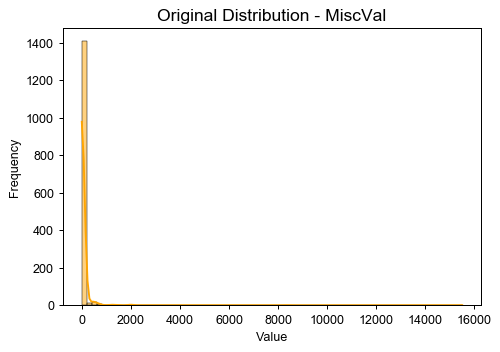

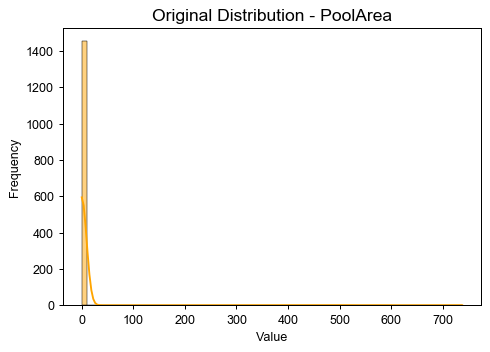

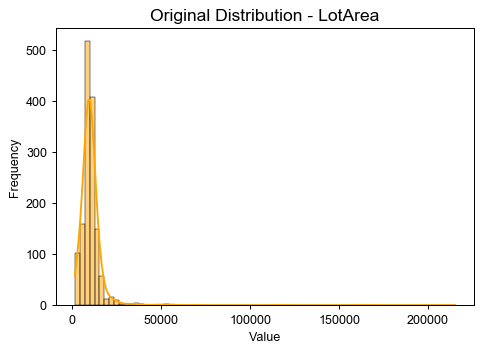

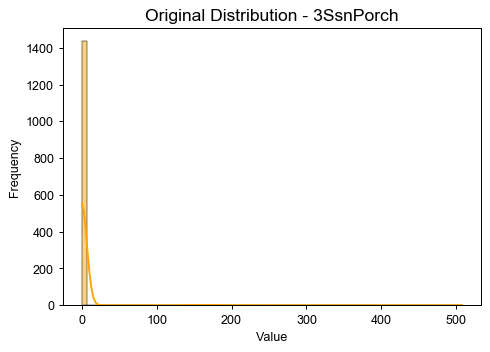

In [5]:
for feature in skewed_feats.index[:4]:
    plt.figure(figsize=(6, 4))
    sns.histplot(data[feature], kde=True, color='orange')
    plt.title(f"Original Distribution - {feature}", fontsize=14)
    plt.xlabel("Value")
    plt.ylabel("Frequency")
    plt.show()

![原文参考图，当前结果见代码输出](attachments/img_017.png)

![原文参考图，当前结果见代码输出](attachments/img_018.png)

#### 第三步：数据转换处理（包含多种转换）

##### 1. 对数变换（Log Transform）

In [6]:
data_log = data.copy()
for feat in skewed_feats.index:
    data_log[feat] = np.log1p(data_log[feat])  # log(1+x)，避免log(0)

偏度较高的数值通常集中在低值区域，尾部过长，不利于模型学习。对数变换压缩极端值，使分布趋于对称。

**可视化对比：**

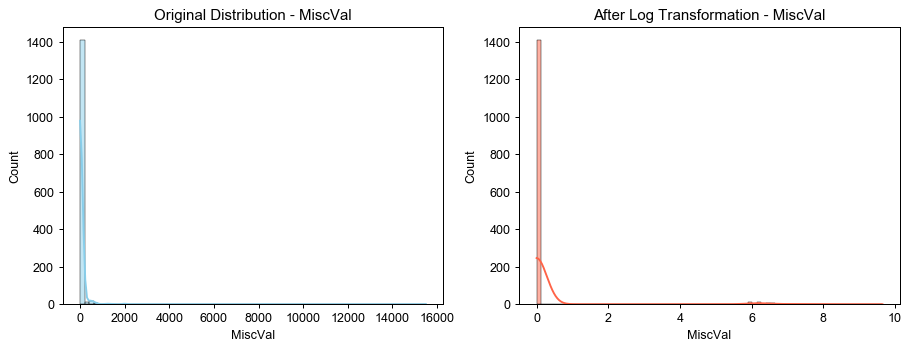

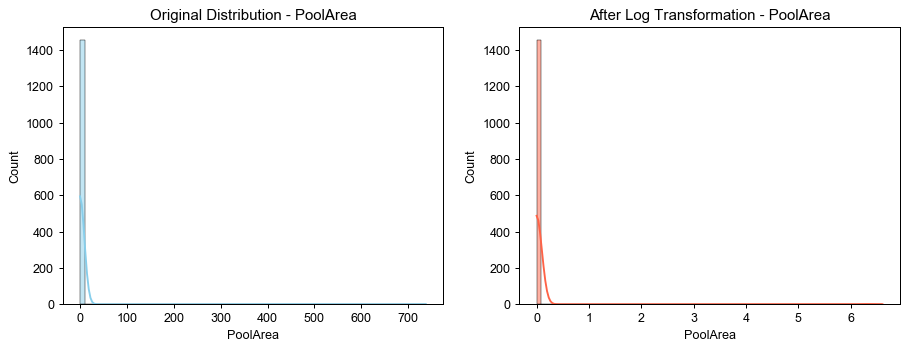

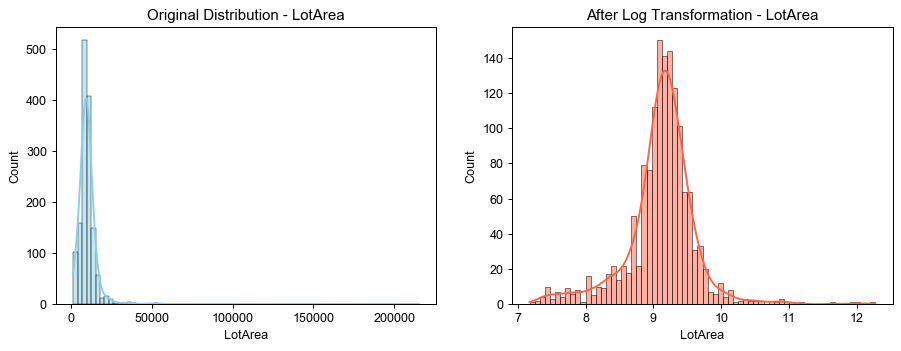

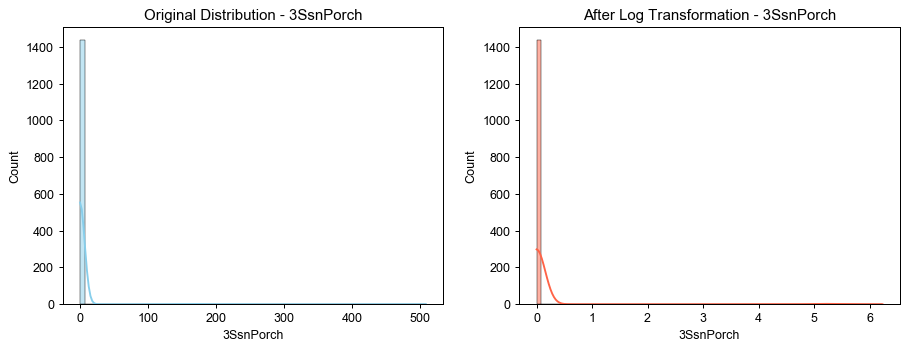

In [7]:
for feature in skewed_feats.index[:4]:
    fig, ax = plt.subplots(1, 2, figsize=(12, 4))
    sns.histplot(data[feature], ax=ax[0], kde=True, color='skyblue')
    sns.histplot(data_log[feature], ax=ax[1], kde=True, color='tomato')
    ax[0].set_title(f"Original Distribution - {feature}")
    ax[1].set_title(f"After Log Transformation - {feature}")
    plt.show()

![原文参考图，当前结果见代码输出](attachments/img_019.png)

![原文参考图，当前结果见代码输出](attachments/img_020.png)

##### 2. 标准化（Standardization）

In [8]:
# 填充数值变量缺失值（用中位数）
data_log[numeric_feats] = data_log[numeric_feats].fillna(data_log[numeric_feats].median())

# 标准化数值特征
scaler = StandardScaler()
scaled_feats = scaler.fit_transform(data_log[numeric_feats])
scaled_data = pd.DataFrame(scaled_feats, columns=numeric_feats)

使所有特征均值为0，标准差为1，有助于模型更快收敛，特别适合基于梯度的优化算法。

##### 3. 分箱（Binning）

我们对房龄进行分箱。

In [9]:
# 创建YearBuilt的分箱变量
data_log['YearBuiltBin'] = pd.cut(data_log['YearBuilt'], bins=[1870, 1900, 1950, 2000, 2010],
                                  labels=['VeryOld', 'Old', 'Modern', 'New'])

将年份这种连续变量转为有语义的分类，有助于建模的解释性和稳定性，尤其适合决策树等模型。

##### 4. One-Hot 编码

In [10]:
# 填充分类变量缺失值（用众数）
categorical_cols = ['YearBuiltBin', 'Neighborhood', 'HouseStyle']
for col in categorical_cols:
    data_log[col] = data_log[col].fillna(data_log[col].mode()[0])

# one-hot编码
data_encoded = pd.get_dummies(data_log[categorical_cols], drop_first=True)

# 合并数值和编码后的分类数据
final_data = pd.concat([scaled_data, data_encoded], axis=1)

将分类变量变为独热向量，避免模型误解类别间的顺序关系。

#### 第四步：PCA降维处理

In [11]:
# PCA降维，保留95%方差
pca = PCA(n_components=0.95)
X_pca = pca.fit_transform(final_data)

print("Original Feature Dimension：", final_data.shape[1])
print("Reduced Dimension：", X_pca.shape[1])

Original Feature Dimension： 72
Reduced Dimension： 31


PCA可剔除冗余特征，压缩数据，提高模型效率，同时降低过拟合风险。

#### 第五步：建模与评估

##### 准备训练集

In [12]:
# 目标变量对数化
y = np.log1p(data_log['SalePrice'])

# 划分训练集测试集
X_train, X_test, y_train, y_test = train_test_split(X_pca, y, test_size=0.2, random_state=42)

##### 模型训练（岭回归）

In [13]:
# 训练岭回归模型
model = Ridge(alpha=1.0)
model.fit(X_train, y_train)

# 预测和评估
y_pred = model.predict(X_test)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
print("Model RMSE (in Log Space)：", rmse)

Model RMSE (in Log Space)： 0.008594853636885433


#### 第六步：结果可视化与分析

##### 实际预测 vs 实际房价

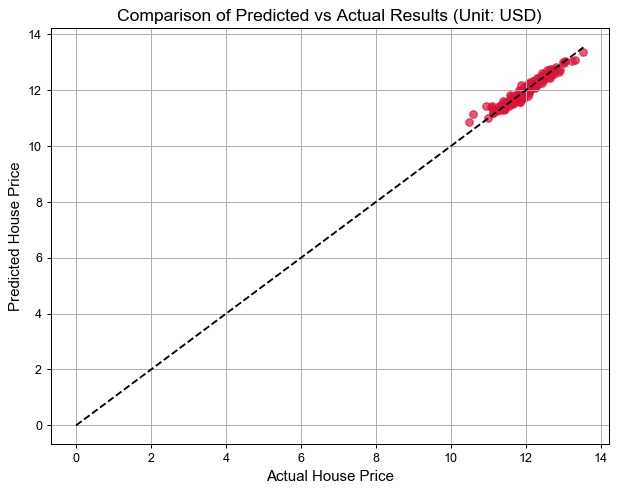

In [14]:
# 预测结果可视化
plt.figure(figsize=(8, 6))
plt.scatter(np.expm1(y_test), np.expm1(y_pred), color='crimson', alpha=0.7)
plt.xlabel("Actual House Price", fontsize=12)
plt.ylabel("Predicted House Price", fontsize=12)
plt.title("Comparison of Predicted vs Actual Results (Unit: USD)", fontsize=14)

max_price = max(np.expm1(y_test).max(), np.expm1(y_pred).max())
plt.plot([0, max_price], [0, max_price], '--', color='black')

plt.grid(True)
plt.show()

![原文参考图，当前结果见代码输出](attachments/img_021.png)

图中如果点均匀分布在对角线上，说明预测较为准确。偏离越远表示预测误差越大。

#### 第七步：优化建议与转换策略总结

##### 优化点分析：

- PCA虽然压缩特征，但可能损失可解释性，适用于规模特征冗余数据。
- 部分分类变量独热编码后维度过高，可考虑目标编码等方法。
- 模型RMSE可以通过加入更多高级转换如 `Box-Cox` 或构造交叉特征进一步优化。

## 模型分析

### 优缺点分析

**优点：**

1. **增强模型表达能力**：数据转换帮助模型更好地理解特征背后的结构。例如对数变换后偏态分布特征更接近正态，岭回归等线性模型可以更充分学习这些关系。
2. **提升训练效率**：经过标准化或归一化处理后，数值特征处于相似尺度，有助于加快梯度下降收敛速度，特别是在神经网络或带正则项的模型中表现更明显。
3. **减少异常值干扰**：对数变换或分箱可以压缩极端数值影响，提升模型鲁棒性。例如将 10 万美元与 200 万美元之间的房价拉近，有助于回归模型拟合。
4. **构建更易解释的特征空间**：分箱操作将连续特征转化为类别，使模型输出更易于人类理解（如“房龄较旧的房屋更便宜”），便于业务解读和可视化。
5. **数据降维与噪声消除**：PCA等线性变换方法有效降低特征维度，减少冗余，提高计算效率，适用于大量数值特征的场景。

**缺点：**

1. **可能丢失原始数据语义**：尤其是 PCA 等无监督变换，转换后各主成分无法直接对应原始特征，模型的可解释性明显下降。
2. **需要专业判断进行选择**：不同类型的特征适用不同的转换方式，若转换方法选错（如对线性特征误用非线性变换），可能反而破坏特征表达。
3. **增加前期处理复杂度**：多种变换方法叠加需要写大量代码并调试，数据清洗、可视化、分箱、标准化等操作会显著增加工作量。
4. **不适用于所有模型**：某些模型（如决策树、随机森林）对数据尺度和分布并不敏感，标准化、PCA等预处理反而可能无益甚至有害。

### 与其他相似算法的对比

| 算法/技术 | 优点 | 缺点 | 适用场景 |
|-|-|-|-|
| **数据转换（本案例）** | 多样灵活，可控性强，适配多种模型，便于人类理解 | 易引入复杂度，需经验选择 | 大多数结构化数据建模场景 |
| **特征构造（如多项式、交互项）** | 提升非线性模型能力，可提升表现 | 高维灾难、过拟合风险高 | 样本量足、非线性关系明显的模型 |
| **自动特征选择（如Lasso、树模型重要性）** | 自动降维，消除冗余特征 | 无法修正特征分布，无法增加表达力 | 特征维度高时的快速建模 |
| **树模型专用特征处理（不转换）** | 可直接处理原始数据，无需归一化，容忍离群值 | 无法应用于其他非树模型 | 使用随机森林、XGBoost、LightGBM等模型 |
| **目标编码** | 保留类别与目标变量的关系，可替代One-Hot减少维度 | 有泄漏风险，需交叉验证处理 | 类别变量很多且有明显信息时 |
| **深度学习自动特征提取** | 无需手动转换，可建模复杂模式 | 数据需求量大，不易解释 | 图像、文本、超高维结构化数据 |

### 何时使用数据转换，何时选择其他方法？

#### 适合使用数据转换的情况：

- **结构化表格数据**：如金融、房地产、医疗等领域，字段类型丰富，需要控制变量尺度与分布。
- **使用线性模型或正则化模型**：如线性回归、Ridge、Lasso、SVM，强烈依赖数据分布与数值尺度。
- **存在极端值或偏态特征**：对数变换等能有效缓解偏态和极端值影响。
- **样本量不大，需要压缩维度**：PCA等降维可增强泛化能力。

#### 不建议使用数据转换的情况：

- **模型对尺度不敏感**：如决策树、XGBoost，不需标准化和归一化。
- **特征含义重要性高，需可解释性**：如医疗诊断、金融信贷评估，PCA会损失可解释性。
- **类别特征稀疏而复杂**：One-Hot编码会导致维度膨胀，可能引发稀疏矩阵计算瓶颈，此时目标编码更优。